In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

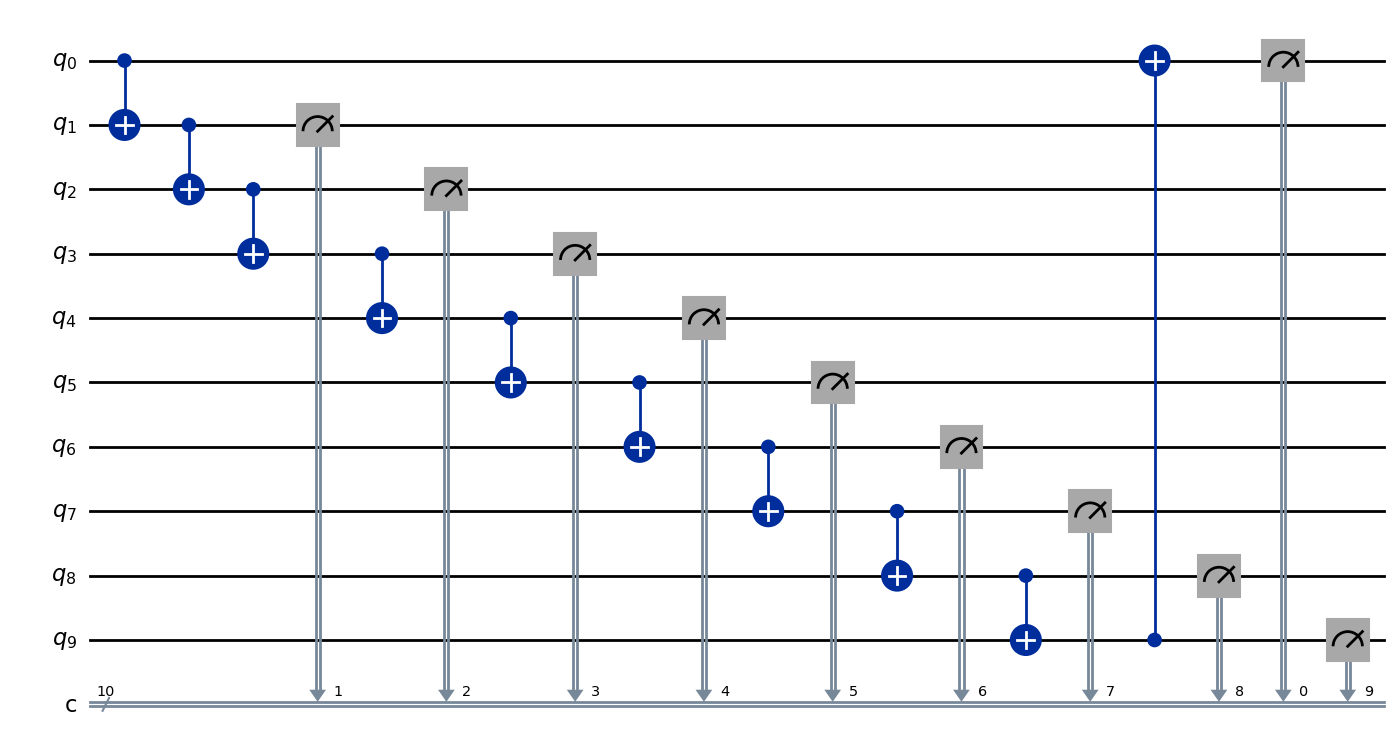

In [2]:
qc = QuantumCircuit(10, 10)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 5)
qc.cx(5, 6)
qc.cx(6, 7)
qc.cx(7, 8)
qc.cx(8, 9)
qc.cx(9, 0)
qc.measure([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
qc.draw("mpl")

# Simulated Hardware
## Run the circuit 50 times with the custom transpiler and then with the Qiskit transpiler

In [3]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [4]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0000000000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.1345703125
Errors for each run: [0.1279296875, 0.1357421875, 0.1279296875, 0.150390625, 0.138671875, 0.1318359375, 0.1328125, 0.111328125, 0.1416015625, 0.146484375, 0.1318359375, 0.146484375, 0.1328125, 0.146484375, 0.134765625, 0.1357421875, 0.1220703125, 0.1474609375, 0.1279296875, 0.138671875, 0.140625, 0.1376953125, 0.1484375, 0.1357421875, 0.1259765625, 0.125, 0.1435546875, 0.130859375, 0.1318359375, 0.1572265625, 0.138671875, 0.1318359375, 0.1318359375, 0.140625, 0.1279296875, 0.1328125, 0.142578125, 0.1279296875, 0.138671875, 0.1298828125, 0.1416015625, 0.138671875, 0.1513671875, 0.142578125, 0.126953125, 0.1259765625, 0.1201171875, 0.10546875, 0.1298828125, 0.1171875]


In [1]:
import numpy as np
errors = [0.1279296875, 0.1357421875, 0.1279296875, 0.150390625, 0.138671875, 0.1318359375, 0.1328125, 0.111328125, 0.1416015625, 0.146484375, 0.1318359375, 0.146484375, 0.1328125, 0.146484375, 0.134765625, 0.1357421875, 0.1220703125, 0.1474609375, 0.1279296875, 0.138671875, 0.140625, 0.1376953125, 0.1484375, 0.1357421875, 0.1259765625, 0.125, 0.1435546875, 0.130859375, 0.1318359375, 0.1572265625, 0.138671875, 0.1318359375, 0.1318359375, 0.140625, 0.1279296875, 0.1328125, 0.142578125, 0.1279296875, 0.138671875, 0.1298828125, 0.1416015625, 0.138671875, 0.1513671875, 0.142578125, 0.126953125, 0.1259765625, 0.1201171875, 0.10546875, 0.1298828125, 0.1171875]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.1345703125
Standard deviation of errors over 50 runs: 0.009985799243097044
0.1346 ± 0.0028 (95% CI)


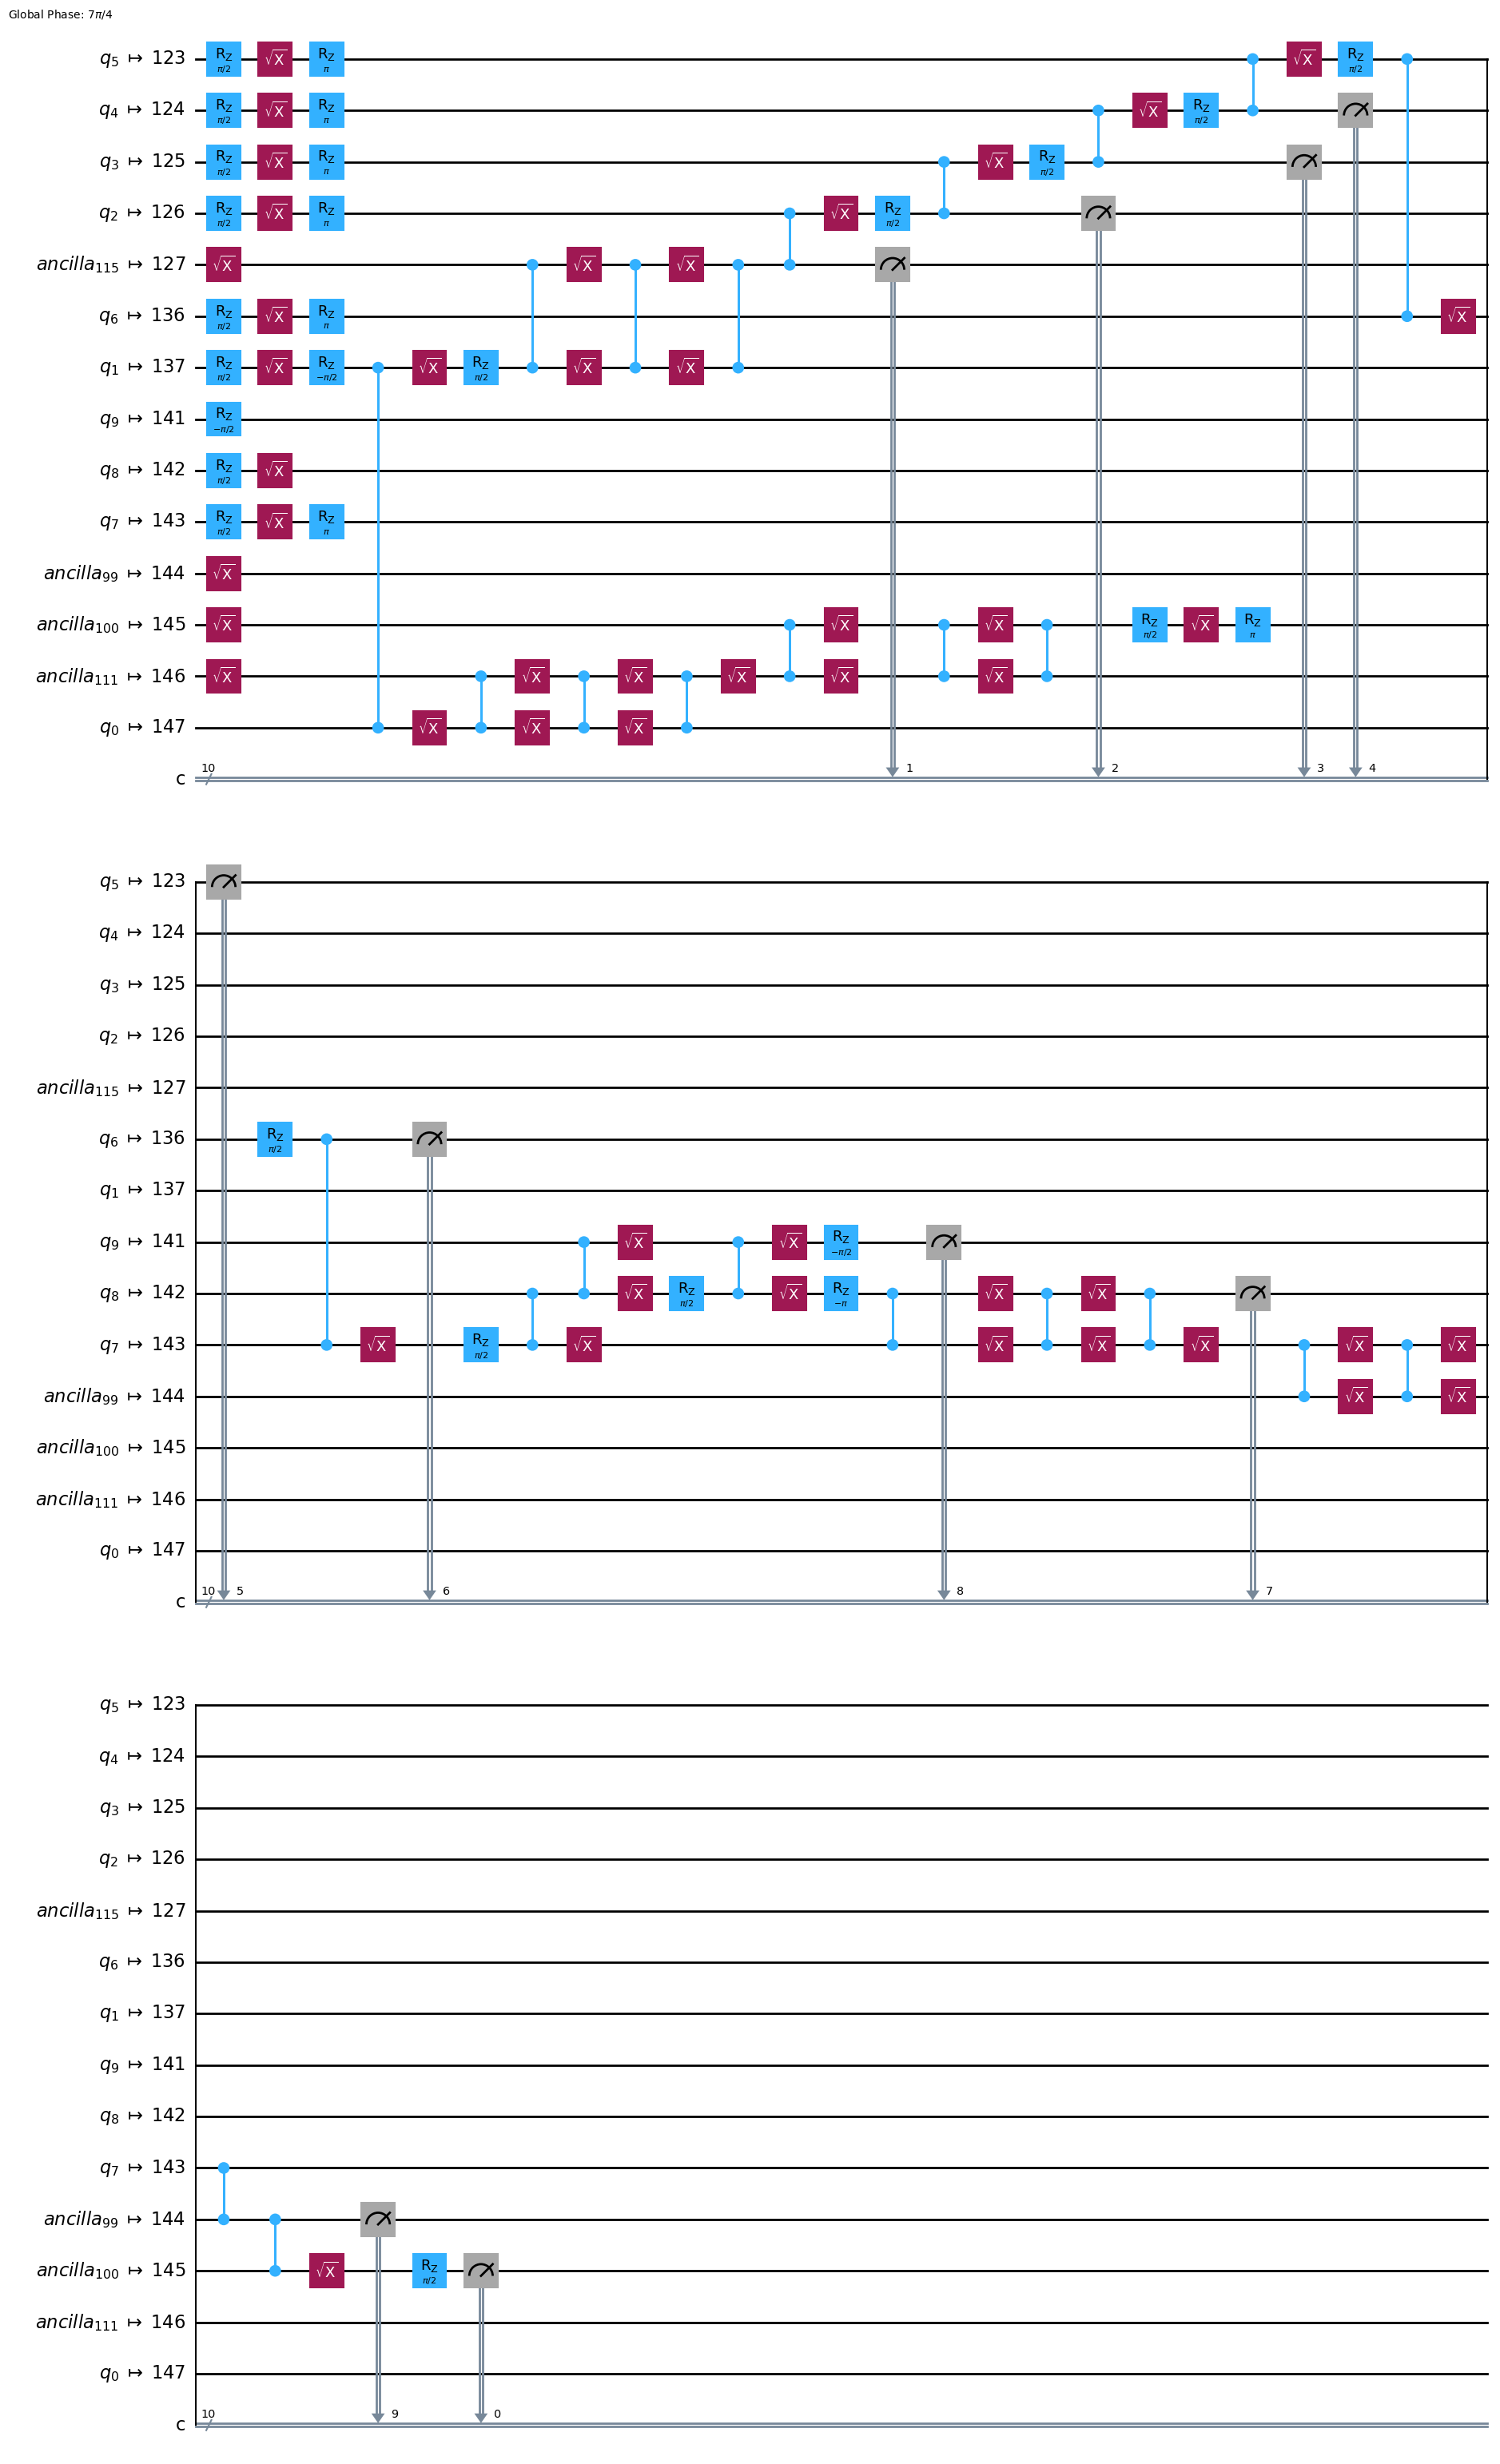

In [5]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [6]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0000000000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.10619140625
Errors for each run: [0.1025390625, 0.1123046875, 0.0810546875, 0.10546875, 0.10546875, 0.1142578125, 0.111328125, 0.103515625, 0.109375, 0.099609375, 0.1044921875, 0.087890625, 0.111328125, 0.1025390625, 0.1279296875, 0.095703125, 0.1103515625, 0.1142578125, 0.091796875, 0.109375, 0.1103515625, 0.1162109375, 0.10546875, 0.09765625, 0.1005859375, 0.1044921875, 0.103515625, 0.103515625, 0.1220703125, 0.1171875, 0.1064453125, 0.1103515625, 0.095703125, 0.1142578125, 0.091796875, 0.1123046875, 0.107421875, 0.103515625, 0.1083984375, 0.1044921875, 0.111328125, 0.1025390625, 0.103515625, 0.1162109375, 0.099609375, 0.119140625, 0.0947265625, 0.11328125, 0.1064453125, 0.1064453125]


In [2]:
import numpy as np
errors = [0.1025390625, 0.1123046875, 0.0810546875, 0.10546875, 0.10546875, 0.1142578125, 0.111328125, 0.103515625, 0.109375, 0.099609375, 0.1044921875, 0.087890625, 0.111328125, 0.1025390625, 0.1279296875, 0.095703125, 0.1103515625, 0.1142578125, 0.091796875, 0.109375, 0.1103515625, 0.1162109375, 0.10546875, 0.09765625, 0.1005859375, 0.1044921875, 0.103515625, 0.103515625, 0.1220703125, 0.1171875, 0.1064453125, 0.1103515625, 0.095703125, 0.1142578125, 0.091796875, 0.1123046875, 0.107421875, 0.103515625, 0.1083984375, 0.1044921875, 0.111328125, 0.1025390625, 0.103515625, 0.1162109375, 0.099609375, 0.119140625, 0.0947265625, 0.11328125, 0.1064453125, 0.1064453125]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.10619140625
Standard deviation of errors over 50 runs: 0.008604418981022285
0.1062 ± 0.0024 (95% CI)


# REAL QUANTUM HARDWARE
## We run each circuit 10 times with the custom transpiler and 10 times with the Qiskit transpiler

In [7]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_marrakesh 156 0
ibm_kingston 156 0


In [10]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [11]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7ea5l95a5qc73dqn9kg
Job ID: d7ea5ljklj2c73f2hfo0
Job ID: d7ea5lrklj2c73f2hfpg
Job ID: d7ea5m3klj2c73f2hfq0
Job ID: d7ea5m95a5qc73dqn9mg
Job ID: d7ea5mh5a5qc73dqn9n0
Job ID: d7ea5mrklj2c73f2hfsg
Job ID: d7ea5n3klj2c73f2hft0
Job ID: d7ea5n95a5qc73dqn9og
Job ID: d7ea5njklj2c73f2hfvg


In [12]:
job_ids = [
    "d7ea5l95a5qc73dqn9kg",
    "d7ea5ljklj2c73f2hfo0",
    "d7ea5lrklj2c73f2hfpg",
    "d7ea5m3klj2c73f2hfq0",
    "d7ea5m95a5qc73dqn9mg",
    "d7ea5mh5a5qc73dqn9n0",
    "d7ea5mrklj2c73f2hfsg",
    "d7ea5n3klj2c73f2hft0",
    "d7ea5n95a5qc73dqn9og",
    "d7ea5njklj2c73f2hfvg",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0000000000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7ea5l95a5qc73dqn9kg: error = 0.2920
Job d7ea5ljklj2c73f2hfo0: error = 0.2754
Job d7ea5lrklj2c73f2hfpg: error = 0.2852
Job d7ea5m3klj2c73f2hfq0: error = 0.3047
Job d7ea5m95a5qc73dqn9mg: error = 0.2842
Job d7ea5mh5a5qc73dqn9n0: error = 0.2793
Job d7ea5mrklj2c73f2hfsg: error = 0.2871
Job d7ea5n3klj2c73f2hft0: error = 0.2891
Job d7ea5n95a5qc73dqn9og: error = 0.3145
Job d7ea5njklj2c73f2hfvg: error = 0.2910

Average error over runs: 0.290234375


Running on: ibm_fez (156 qubits)


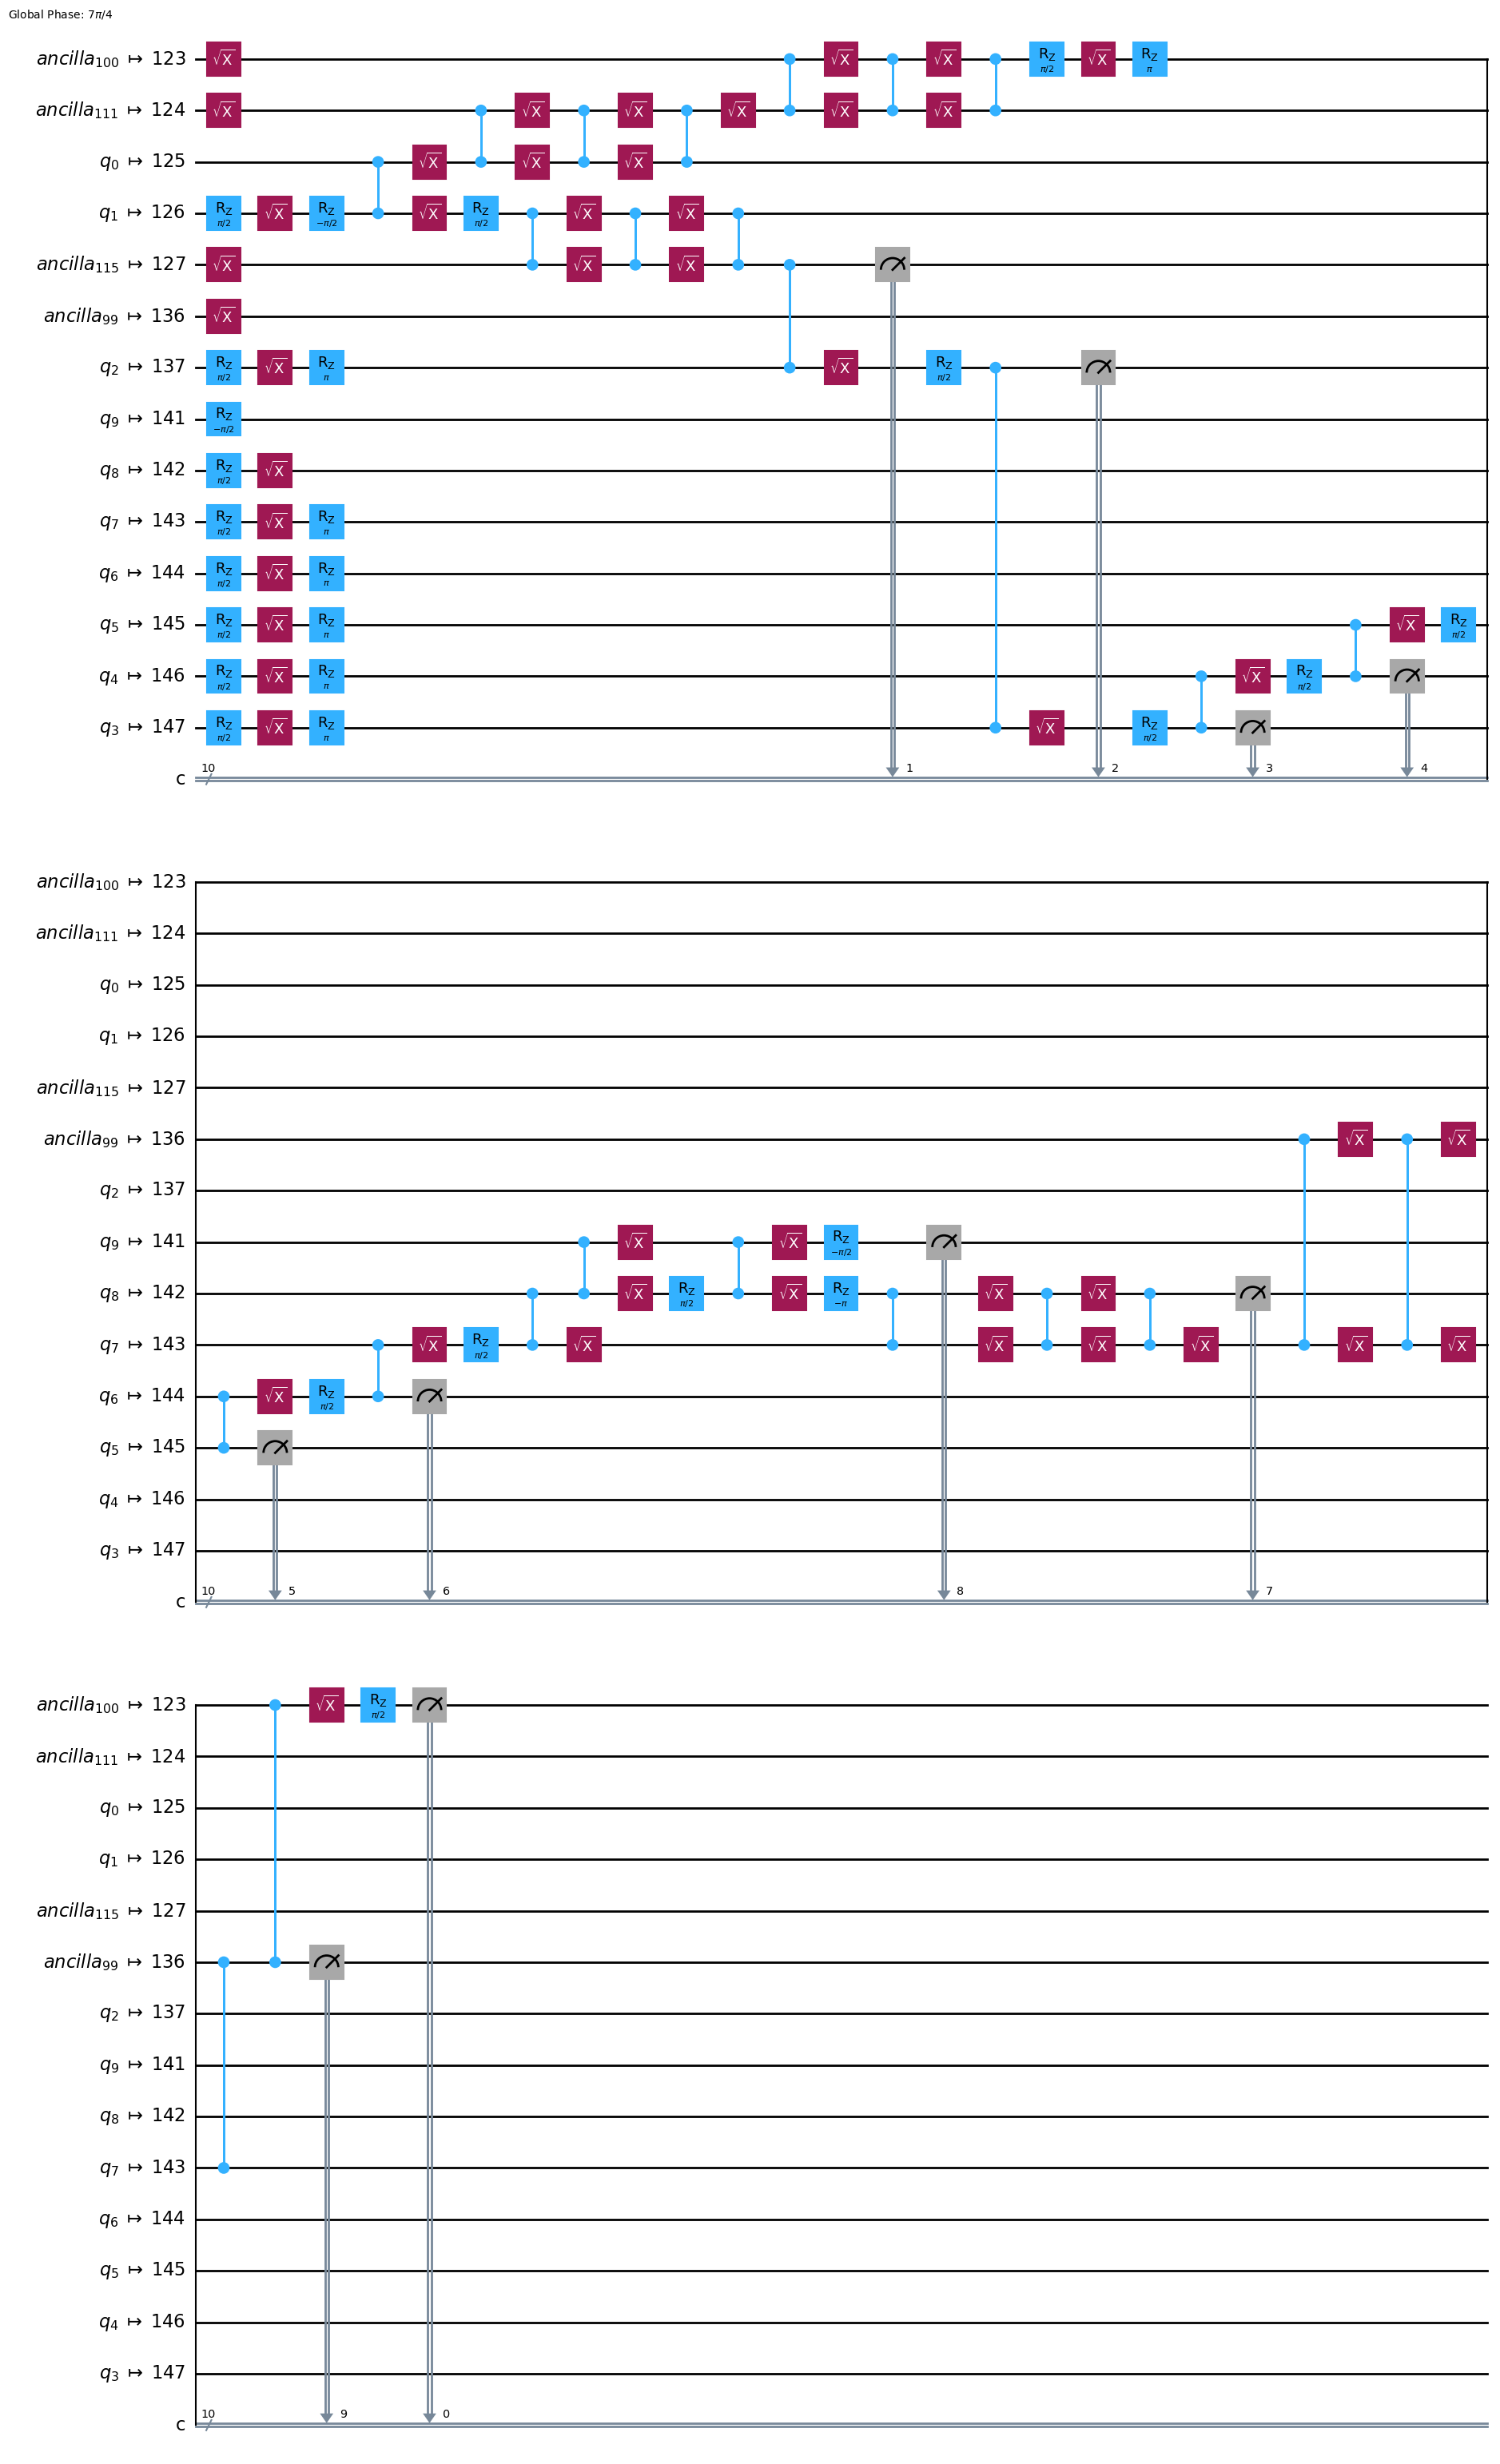

In [13]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")
# qc.draw("mpl")

In [14]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7ea6j3klj2c73f2hgt0
Job ID: d7ea6je5nvhs73a6h930
Job ID: d7ea6jjklj2c73f2hgu0
Job ID: d7ea6ju5nvhs73a6h94g
Job ID: d7ea6k3klj2c73f2hgv0
Job ID: d7ea6k95a5qc73dqnapg
Job ID: d7ea6kjklj2c73f2hh10
Job ID: d7ea6kp5a5qc73dqnaqg
Job ID: d7ea6l65nvhs73a6h960
Job ID: d7ea6lbklj2c73f2hh30


In [16]:
job_ids = [
    "d7ea6j3klj2c73f2hgt0",
    "d7ea6je5nvhs73a6h930",
    "d7ea6jjklj2c73f2hgu0",
    "d7ea6ju5nvhs73a6h94g",
    "d7ea6k3klj2c73f2hgv0",
    "d7ea6k95a5qc73dqnapg",
    "d7ea6kjklj2c73f2hh10",
    "d7ea6kp5a5qc73dqnaqg",
    "d7ea6l65nvhs73a6h960",
    "d7ea6lbklj2c73f2hh30",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0000000000":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7ea6j3klj2c73f2hgt0: error = 0.2178
Job d7ea6je5nvhs73a6h930: error = 0.2119
Job d7ea6jjklj2c73f2hgu0: error = 0.2041
Job d7ea6ju5nvhs73a6h94g: error = 0.2080
Job d7ea6k3klj2c73f2hgv0: error = 0.2314
Job d7ea6k95a5qc73dqnapg: error = 0.2100
Job d7ea6kjklj2c73f2hh10: error = 0.2070
Job d7ea6kp5a5qc73dqnaqg: error = 0.2148
Job d7ea6l65nvhs73a6h960: error = 0.1875
Job d7ea6lbklj2c73f2hh30: error = 0.2002

Average error over runs: 0.20927734375


In [3]:
import time
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("Original circuit:")
print(f"No. of Gates: {qc.size()}")
print(f"Depth: {qc.depth()}\n")

print("My transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

from qiskit import transpile

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("\nQiskit transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:
No. of Gates: 20
Depth: 11

My transpiler:
No. of Gates: 416
Depth: 242
Transpilation time: 1.9625 seconds

Qiskit transpiler:
No. of Gates: 114
Depth: 51
Transpilation time: 0.0485 seconds


In [7]:
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

transpiled_circuit = transpile(qc, backend)

print("Original circuit:")

twoq = sum(1 for inst in qc.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in qc.data if len(inst.qubits) == 1)

print(f"\nOriginal circuit: {twoq} two-qubit gates, {oneq} single-qubit gates")

print("\nMy transpiler:")
twoq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 1)

print(f"\n {twoq} two-qubit gates, {oneq} single-qubit gates")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)


print("\nQiskit transpiler:")

twoq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 1)

print(f"\n {twoq} two-qubit gates, {oneq} single-qubit gates")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:

Original circuit: 10 two-qubit gates, 10 single-qubit gates

My transpiler:

 58 two-qubit gates, 358 single-qubit gates

Qiskit transpiler:

 26 two-qubit gates, 88 single-qubit gates
